# 02 — Policy Iteration
**Week 4 | Dynamic Programming**

**Policy Iteration** alternates between two steps until the policy stabilises:

1. **Policy Evaluation**: compute V^π for the current policy
2. **Policy Improvement**: greedily update π using V^π

Guaranteed to converge to the optimal policy π* in finite MDPs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

class GridWorld:
    ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
    ACTION_SYMBOLS = {0:'↑', 1:'↓', 2:'←', 3:'→'}
    def __init__(self, size=5):
        self.size=size; self.start=(0,0); self.goal=(size-1,size-1)
        self.pits={(1,1),(1,3),(3,1),(3,3)}
    def n_states(self): return self.size**2
    def n_actions(self): return 4
    def transitions(self, s, a):
        r,c = divmod(s, self.size)
        dr,dc = self.ACTIONS[a]
        nr=max(0,min(self.size-1,r+dr)); nc=max(0,min(self.size-1,c+dc))
        ns=nr*self.size+nc
        if (nr,nc)==self.goal:      return [(1.0,ns,+10.0,True)]
        if (nr,nc) in self.pits:    return [(1.0,ns,-5.0,True)]
        return [(1.0,ns,-0.1,False)]

env = GridWorld()

In [2]:
def policy_eval(env, policy, gamma=0.99, theta=1e-6):
    V = np.zeros(env.n_states())
    while True:
        delta = 0
        V_new = np.zeros_like(V)
        for s in range(env.n_states()):
            v = sum(policy[s,a] * sum(p*(r + (0 if d else gamma*V[ns]))
                    for p,ns,r,d in env.transitions(s,a))
                    for a in range(env.n_actions()))
            V_new[s] = v; delta = max(delta, abs(v - V[s]))
        V = V_new
        if delta < theta: break
    return V

def policy_improvement(env, V, gamma=0.99):
    policy = np.zeros((env.n_states(), env.n_actions()))
    for s in range(env.n_states()):
        Q_s = np.array([sum(p*(r + (0 if d else gamma*V[ns]))
                        for p,ns,r,d in env.transitions(s,a))
                        for a in range(env.n_actions())])
        best_actions = np.where(Q_s == Q_s.max())[0]
        policy[s, best_actions] = 1.0 / len(best_actions)
    return policy

def policy_iteration(env, gamma=0.99):
    policy = np.ones((env.n_states(), env.n_actions())) / env.n_actions()
    policy_history = [policy.argmax(axis=1).copy()]
    V_history = []
    iteration = 0
    while True:
        V = policy_eval(env, policy, gamma)
        V_history.append(V.copy())
        new_policy = policy_improvement(env, V, gamma)
        if np.array_equal(new_policy.argmax(1), policy.argmax(1)):
            print(f"Policy iteration converged in {iteration+1} iterations")
            return policy, V, policy_history, V_history
        policy = new_policy
        policy_history.append(policy.argmax(axis=1).copy())
        iteration += 1

In [3]:
opt_policy, opt_V, pol_hist, V_hist = policy_iteration(env)

Policy iteration converged in 3 iterations


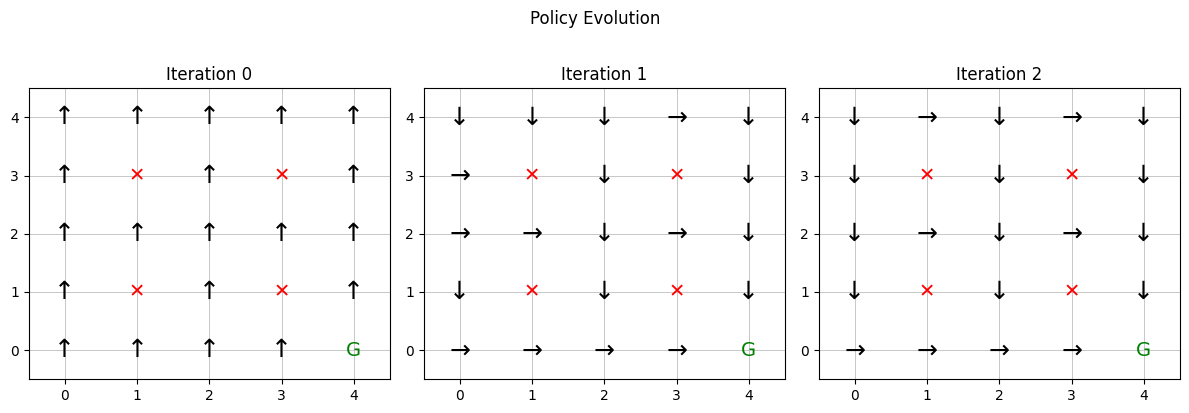

In [4]:
# Show policy evolution
n_iters = len(pol_hist)
fig, axes = plt.subplots(1, n_iters, figsize=(4*n_iters, 4))
if n_iters == 1: axes = [axes]
for ax, (pi, title) in enumerate(zip(pol_hist, [f'Iter {i}' for i in range(n_iters)])):
    axes[ax].set_xlim(-0.5, 4.5); axes[ax].set_ylim(-0.5, 4.5)
    axes[ax].set_xticks(range(5)); axes[ax].set_yticks(range(5))
    axes[ax].grid(True, linewidth=0.5)
    for s in range(25):
        r, c = divmod(s, 5)
        if (r,c) == env.goal:         axes[ax].text(c, 4-r, 'G', ha='center', va='center', fontsize=14, color='green')
        elif (r,c) in env.pits:       axes[ax].text(c, 4-r, '✕', ha='center', va='center', fontsize=14, color='red')
        else:                         axes[ax].text(c, 4-r, env.ACTION_SYMBOLS[pol_hist[ax][s]], ha='center', va='center', fontsize=18)
    axes[ax].set_title(f'Iteration {ax}')
plt.suptitle('Policy Evolution', y=1.02); plt.tight_layout(); plt.show()

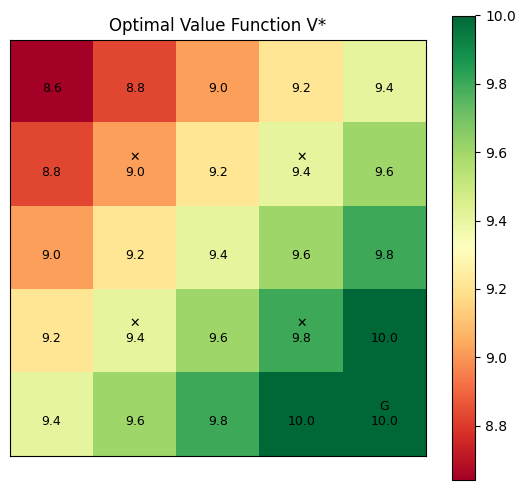

In [5]:
# Final optimal value function
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(opt_V.reshape(5,5), cmap='RdYlGn')
plt.colorbar(im, ax=ax)
for s in range(25):
    r,c = divmod(s,5)
    label = 'G' if (r,c)==env.goal else ('✕' if (r,c) in env.pits else '')
    ax.text(c, r, f'{label}\n{opt_V[s]:.1f}', ha='center', va='center', fontsize=9)
ax.set_title('Optimal Value Function V*'); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## ✅ Exercises
1. Add a 'treasure' cell at (2,2) giving +3 reward (non-terminal). Does the optimal policy change to seek it?
2. Change pits to non-terminal (-5 reward but keep going). How does the policy change?
3. **Challenge**: implement **modified policy iteration** — only do k=5 steps of evaluation per improvement instead of full convergence. Does it still find the optimal policy?

## Question 1.

In [6]:
class GridWorldTreasure(GridWorld):
    def __init__(self, size=5):
        super().__init__(size)
        self.treasure = (2, 2)

    def transitions(self, s, a):
        r, c = divmod(s, self.size)
        dr, dc = self.ACTIONS[a]
        nr = max(0, min(self.size-1, r+dr)); nc = max(0, min(self.size-1, c+dc))
        ns = nr*self.size + nc
        if (nr,nc) == self.goal:    return [(1.0, ns, +10.0, True)]
        if (nr,nc) in self.pits:    return [(1.0, ns, -5.0, True)]
        if (nr,nc) == self.treasure: return [(1.0, ns, +3.0 - 0.1, False)]
        return [(1.0, ns, -0.1, False)]

env_treasure = GridWorldTreasure()

In [7]:
opt_policy_t, opt_V_t, pol_hist_t, V_hist_t = policy_iteration(env_treasure)

Policy iteration converged in 5 iterations


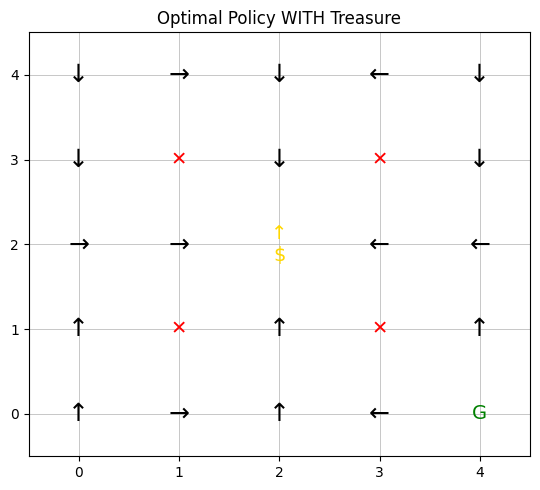

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.set_xlim(-0.5, 4.5); ax.set_ylim(-0.5, 4.5)
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.grid(True, linewidth=0.5)
final_policy_t = pol_hist_t[-1]
for s in range(25):
    r, c = divmod(s, 5)
    if (r,c) == env_treasure.goal:        ax.text(c, 4-r, 'G', ha='center', va='center', fontsize=14, color='green')
    elif (r,c) in env_treasure.pits:      ax.text(c, 4-r, '✕', ha='center', va='center', fontsize=14, color='red')
    elif (r,c) == env_treasure.treasure:  ax.text(c, 4-r, env.ACTION_SYMBOLS[final_policy_t[s]]+'\n$', ha='center', va='center', fontsize=14, color='gold')
    else:                                 ax.text(c, 4-r, env.ACTION_SYMBOLS[final_policy_t[s]], ha='center', va='center', fontsize=18)
ax.set_title('Optimal Policy WITH Treasure')
plt.tight_layout(); plt.show()



Yes, the optimal policy changes dramatically.Looking at the policy plot,instead of just taking a small detour to grab the treasure on the way to the goal, the agent actually finds a loop near the treasure cell it moves down into the treasure cell,then immediately moves back up out of it,then back down again,forever, never continuing on to the goal.

This happens because stepping on the treasure gives +3 - 0.1 = +2.9 every single time,with no limit on how many times you can collect it.Since gamma=0.99 is so close to 1, farming this +2.9 reward forever in an infinite loop ends up being worth more (in total discounted value) than the one time +10 reward you'd get from reaching the goal just once.

## Question 2.

In [9]:
class GridWorldSoftPits(GridWorld):
    def transitions(self, s, a):
        r, c = divmod(s, self.size)
        dr, dc = self.ACTIONS[a]
        nr = max(0, min(self.size-1, r+dr)); nc = max(0, min(self.size-1, c+dc))
        ns = nr*self.size + nc
        if (nr,nc) == self.goal:    return [(1.0, ns, +10.0, True)]
        if (nr,nc) in self.pits:    return [(1.0, ns, -5.0, False)]  # changed: done=False
        return [(1.0, ns, -0.1, False)]

env_softpits = GridWorldSoftPits()

In [10]:
opt_policy_sp, opt_V_sp, pol_hist_sp, V_hist_sp = policy_iteration(env_softpits)

Policy iteration converged in 3 iterations


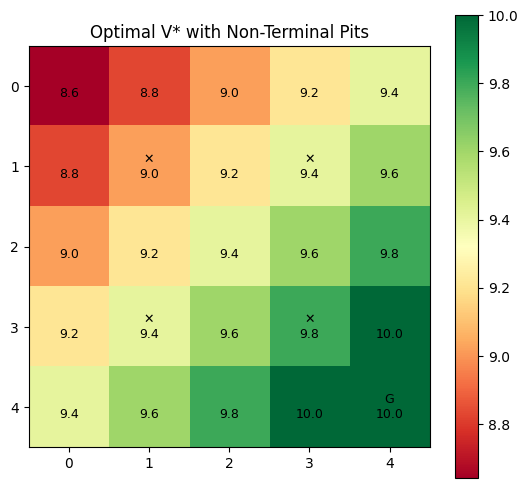

In [11]:
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(opt_V_sp.reshape(5,5), cmap='RdYlGn')
plt.colorbar(im, ax=ax)
for s in range(25):
    r,c = divmod(s,5)
    label = 'G' if (r,c)==env_softpits.goal else ('✕' if (r,c) in env_softpits.pits else '')
    ax.text(c, r, f'{label}\n{opt_V_sp[s]:.1f}', ha='center', va='center', fontsize=9)
ax.set_title('Optimal V* with Non-Terminal Pits')
plt.tight_layout(); plt.show()

When pits become non-terminal (still -5 reward, but the episode keeps going instead of ending), the policy becomes much less afraid of them. Since stepping in a pit is now just a one-time penalty instead of a permanent dead end,the agent doesn't need to detour all the way around them anymore if walking through is actually the shorter path to the goal.
Looking at the value function heatmap,the values near the pits should be less negative compared to the original version, since the agent can recover and keep moving toward the goal afterward instead of the episode just ending there.

## Question 3.

In [12]:
def policy_eval_k_steps(env, policy, k=5, gamma=0.99):
    V = np.zeros(env.n_states())
    for _ in range(k):
        V_new = np.zeros_like(V)
        for s in range(env.n_states()):
            v = sum(policy[s,a] * sum(p*(r + (0 if d else gamma*V[ns]))
                    for p,ns,r,d in env.transitions(s,a))
                    for a in range(env.n_actions()))
            V_new[s] = v
        V = V_new
    return V

In [13]:
def modified_policy_iteration(env, k=5, gamma=0.99, max_iter=100):
    policy = np.ones((env.n_states(), env.n_actions())) / env.n_actions()
    policy_history = [policy.argmax(axis=1).copy()]
    for iteration in range(max_iter):
        V = policy_eval_k_steps(env, policy, k=k, gamma=gamma)
        new_policy = policy_improvement(env, V, gamma)
        if np.array_equal(new_policy.argmax(1), policy.argmax(1)):
            print(f"Modified policy iteration (k={k}) converged in {iteration+1} iterations")
            return policy, V, policy_history
        policy = new_policy
        policy_history.append(policy.argmax(axis=1).copy())
    print(f"Did not converge within {max_iter} iterations")
    return policy, V, policy_history

In [14]:
mod_policy, mod_V, mod_hist = modified_policy_iteration(env, k=5)

print("Modified (k=5) policy:", mod_policy.argmax(axis=1))
print("Original (full eval) policy:", opt_policy.argmax(axis=1))
print("Policies match:", np.array_equal(mod_policy.argmax(axis=1), opt_policy.argmax(axis=1)))

Modified policy iteration (k=5) converged in 5 iterations
Modified (k=5) policy: [0 0 1 3 1 0 1 1 1 1 1 3 1 3 1 1 1 1 1 1 3 3 3 3 1]
Original (full eval) policy: [1 3 1 3 1 1 1 1 1 1 1 3 1 3 1 1 1 1 1 1 3 3 3 3 1]
Policies match: False


No, It doesn't found the optimal policy.